In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
import numpy as np, sys, pickle as pk, healpy as H
from pylab import *

In [24]:
#plot(); show()
rcParams['figure.dpi'] = 150
rcParams['figure.facecolor'] = 'white'

In [25]:
def get_beam_dic(els, freqs, beam_dic = None):
    if beam_dic is None:
        beam_dic = {27: 7.8, 39: 5.3, 93: 2.2, 145: 1.4, 225: 1., 278: 0.9}
    bl_dic =  {}
    for freq in freqs:
        beamval = beam_dic[freq]
        bl_dic[freq] = H.gauss_beam(np.radians(beamval/60.), lmax=len(els)-1)
    return bl_dic

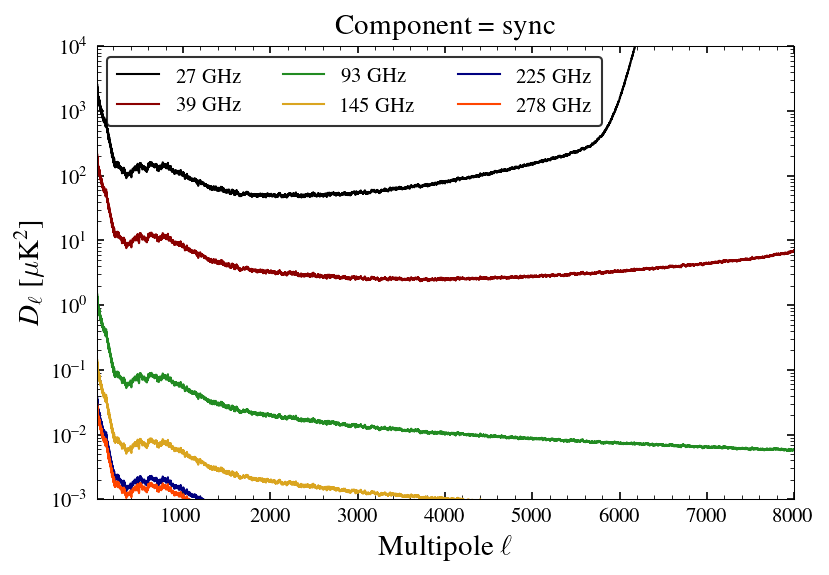

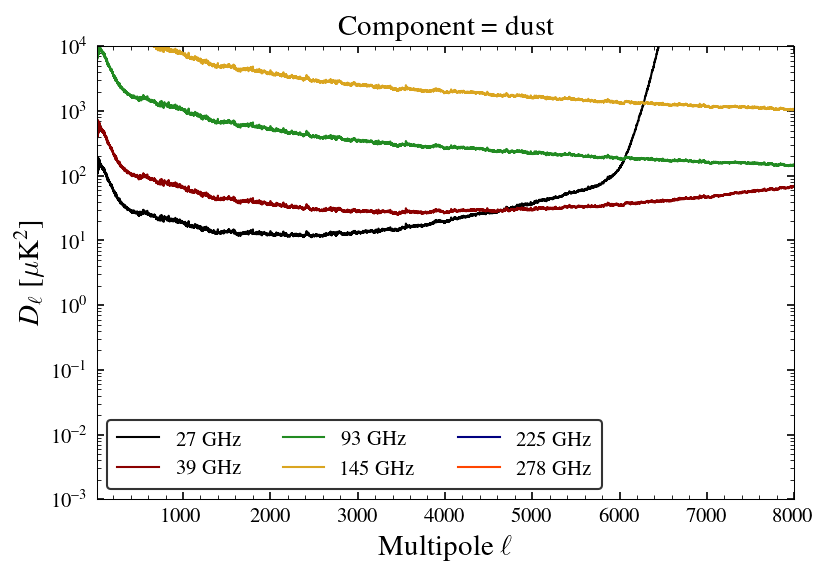

SystemExit: 

In [28]:
fname_dic = {'sync': 'C_ell_synchrotron.pkl', 
             'dust': 'C_ell_dust.pkl', 
            }

name_dic = {}
name_dic[20] = 'ULFL1'
name_dic[27] = 'LFL1'
name_dic[39] = 'LFL2'
name_dic[93] = 'MFL1'
name_dic[145] = 'MFL2'
name_dic[225] = 'HFL1'
name_dic[278] = 'HFL2'

nu_arr = [27, 39, 93, 145, 225, 278]

for comp in fname_dic:
    fname = fname_dic[comp]
    curr_dic = pk.load( open(fname, 'rb') )
    
    cl_tt = curr_dic['LFL1'][0]
    el_ = np.arange(len(cl_tt))
    bl_dic = get_beam_dic(el_, nu_arr)

    #print( curr_dic.keys() )
    clf()
    fsval = 14
    ax = subplot(111, yscale = 'log')
    for nu in nu_arr:
        band = name_dic[nu]
        cl_tt = curr_dic[band][0]
        cl_tt = cl_tt/bl_dic[nu]**2.
        el_ = np.arange(len(cl_tt))
        dl_fac = el_* (el_+1)/2/np.pi
        plot(el_, dl_fac * cl_tt, label = r'%s GHz' %(nu))
    xlim(10, 8000); ylim(1e-3, 1e4)
    legend(loc = 'best', fontsize = fsval-4, ncol = 3)
    title(r'Component = %s' %(comp), fontsize = fsval)
    xlabel(r'Multipole $\ell$', fontsize = fsval); ylabel(r'$D_{\ell}$ [$\mu$K$^{2}$]', fontsize = fsval)
    show(); 
    
sys.exit()
        
        
